# Projeto de Implementação do Fuzzy C-Means

- Enzo Ambrósio (RA: 24008773)
- Giulia Monteiro Garrido (RA: 24010281)
- Thomaz Dacorso (RA: )

## Requisitos

**Requisitos do Projeto:**
1. Implementação e explicação do funcionamento do algoritmo (7pts)

2. Aplicar o algoritmo na base de dados Iris (completa, 4 atributos, 3 classes) e listar as pertinências de cada amostra usando 3 grupos (1pt)

3. Plot de resultados utilizando a base de dados Iris (apenas as amostras virgínica e versicolor) usando 2 grupos. Notem que é importante demonstrar a pertinência intermediária, o que será mais fácil em um problema de binário (2pts)

| **Parâmetros** | **Significado** |
| --- | --- |
| k | N° de grupos |
| m | Fator de difusão/fuzzificação |

| **Fórmulas/Funções** |
| --- |
| Criar pertinências aleatórias |
| Pertinência / w |
| Função objetivo |
| Atualizar centróides |

## Etapa 1

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist

In [11]:
#distancias = cdist(X, centroids, metric='euclidean')

In [12]:
def generate_random_relevence(X,k):
    
    '''
    Atribui a cada item uma relevância aleatória para cada grupo k.
    Garante que a soma de cada linha seja 1.
    '''

    relevences=[]    
    
    for i in range(len(X)):
        relevences.append([])
        aux=0
        sum=0

        for j in range(k):
            relevences[i].append(np.random.uniform(0,1-aux))
            aux+=relevences[i][j]
            sum+=relevences[i][j]

        if sum!=1:
            relevences[i][0]=1-sum+relevences[i][0]

    return np.array(relevences)
    


In [13]:
def pertinencias(X, C, m):
    '''
    X: matriz de amostras
    C: matriz de centróides
    m: parâmetro de fuzziness

    Calcula a pertinência w_ij de xi ao centróide C[j]
    usando cdist para calcular as distâncias euclidianas.
    '''

    # cdist é de matrizes 2D, então fiz o reshape xi para (1, n_features)
    # ai da um o array do shape com a distancia de xi pro centroide

    U=[]

    distancias = cdist(X, C, metric='euclidean')

    exponent = 2 / (m - 1)

    for i in distancias:
        aux_U=[]

        for dist_j in i:
            sum = 0
            
            for dist_l in i:

                if dist_l == 0:
                    sum+=(1.0 if dist_l == dist_j else 0.0)
                else:
                    sum += (dist_j / dist_l) 
                    
            sum = sum ** exponent
            aux_U.append(1 / sum)

        U.append(aux_U)

    return np.array(U)


In [14]:
def centroid_update(X, U, m):

    k = U.shape[1]
    C = []

    for j in range(k):
        numerador = 0
        denominador = 0

        for i in range(len(X)):
            numerador += (U[i][j]**m) * X[i]
            denominador += U[i][j]**m

        C.append(numerador/denominador)
    
    return np.array(C)

In [15]:
def objective_function(X,C,U):

    '''
    X: matriz de dados
    C: matriz de centróides
    U: matriz de pertinência
    Calcula a função objetivo do FCM    
    '''

    n_samples = X.shape[0]
    n_clusters = C.shape[0]
    J = 0
    
    for i in range(n_samples):
        for j in range(n_clusters):
            u_ij = U[i, j]
            J += (u_ij) * (np.linalg.norm(X[i] - C[j]) ** 2)

    return J

In [22]:
def fuzzy_cmeans(X, k, m, max_iter=100, conv = 0.001):

    n_samples = X.shape[0] #n° de linhas

    J_history = []

    U = generate_random_relevence(X, k) #cria a matriz de pertinência aleatória inicial

    C=centroid_update(X, U, m) #inicializa a matriz de centróides

    for iteration in range(max_iter):
        C_old = C.copy()

        C = centroid_update(X, U, m)
        J = objective_function(X, C, U)
        U=pertinencias(X, C, m)

        J_history.append(J)
        convergence = np.linalg.norm(C - C_old)

        if convergence < conv:
            print(f"Convergiu na iteração {iteration}")
            break

    
    return U, C, J_history


## Etapa 2

In [17]:
import seaborn as sns

iris = sns.load_dataset("iris")
X = iris.iloc[:, :4].values # Não usa a coluna 'species'

X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [23]:
U, C, J = fuzzy_cmeans(X, k=3, m=2)

print("Pertinências: \n", np.round(U, 4))
print("Centróides: \n", C)

Convergiu na iteração 0
Pertinências: 
 [[0.1152 0.146  0.0775]
 [0.1149 0.1453 0.0783]
 [0.1148 0.1437 0.0796]
 [0.1147 0.1452 0.0786]
 [0.1152 0.1455 0.0779]
 [0.116  0.149  0.0748]
 [0.1149 0.1445 0.0789]
 [0.1151 0.1473 0.0768]
 [0.1145 0.1424 0.0808]
 [0.1148 0.1463 0.0777]
 [0.1157 0.1467 0.0767]
 [0.1149 0.1477 0.0766]
 [0.1147 0.1445 0.0791]
 [0.1145 0.1394 0.0831]
 [0.1161 0.1404 0.081 ]
 [0.1165 0.1411 0.0802]
 [0.1159 0.1437 0.0787]
 [0.1153 0.1464 0.0772]
 [0.1162 0.1484 0.075 ]
 [0.1155 0.1465 0.077 ]
 [0.1154 0.1509 0.0739]
 [0.1155 0.1473 0.0764]
 [0.1149 0.1401 0.0822]
 [0.1152 0.1523 0.0731]
 [0.1147 0.1517 0.0739]
 [0.1148 0.1483 0.0762]
 [0.1151 0.1496 0.075 ]
 [0.1153 0.1475 0.0764]
 [0.1153 0.1463 0.0773]
 [0.1147 0.1471 0.0771]
 [0.1147 0.1476 0.0768]
 [0.1156 0.1486 0.0753]
 [0.1156 0.1437 0.0789]
 [0.116  0.1421 0.0798]
 [0.1148 0.1468 0.0773]
 [0.1151 0.1435 0.0795]
 [0.1156 0.1445 0.0783]
 [0.1151 0.1447 0.0786]
 [0.1146 0.1418 0.0812]
 [0.1152 0.1475 0.0765]


## Etapa 3

In [24]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [25]:
filtered_iris = iris[iris['species']!='setosa']
X = filtered_iris.iloc[:, :4].values

In [26]:
#filtered_iris['species'].values

In [33]:
U, C, J = fuzzy_cmeans(X, k=2, m=2)

Convergiu na iteração 0


ValueError: 'c' argument has 2 elements, which is inconsistent with 'x' and 'y' with size 3.

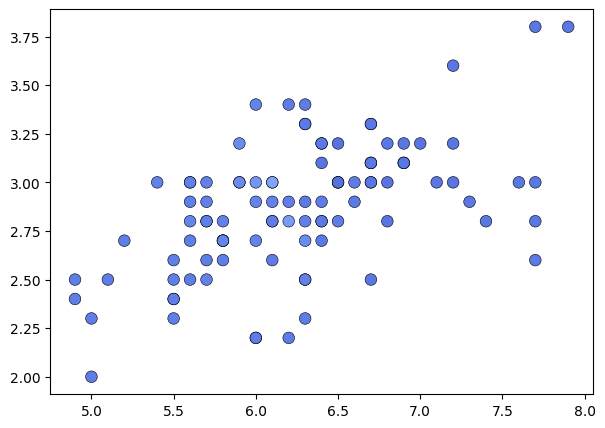

In [32]:
membership = U[:, 0]

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    X[:, 0], X[:, 1],
    c=membership, cmap='coolwarm', vmin=0, vmax=1,
    edgecolors='k', linewidths=0.4, s=70
)

ax.scatter(C[:, 0], C[:, 1], marker='o', s=300, c=['blue', 'red'],
           edgecolors='k', linewidths=0.8, zorder=5, label='Centróides')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Pertinência ao Grupo 0')
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Sepal Width (cm)')
ax.set_title('Fuzzy C-Means (Sepal)\nVersicolor x Virginica')
ax.legend()
plt.tight_layout()
plt.show()

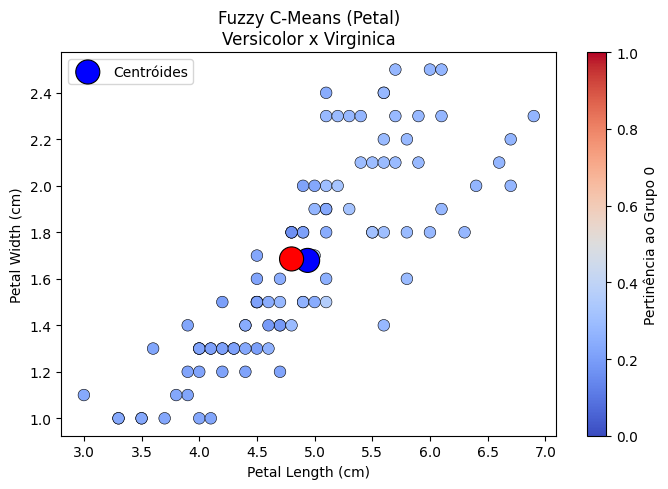

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    X[:, 2], X[:, 3],
    c=membership, cmap='coolwarm', vmin=0, vmax=1,
    edgecolors='k', linewidths=0.4, s=70
)

ax.scatter(C[:, 2], C[:, 3], marker='o', s=300, c=['blue', 'red'],
           edgecolors='k', linewidths=0.8, zorder=5, label='Centróides')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Pertinência ao Grupo 0')
ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_title('Fuzzy C-Means (Petal)\nVersicolor x Virginica')
ax.legend()
plt.tight_layout()
plt.show()